# Data Analysis of Book Tropes

## Project Overview

This project explores how different story elements (tropes) relate to reader engagement and ratings using Goodreads book data.

The goal of this project is to demonstrate data analysis skills while exploring patterns in publishing and reader preferences.

The dataset is a cleaned Goodreads dataset imported from Kaggle.

I plan to analyse:
* What makes books popular or highly rated?
* Do length and tropes affect ratings or engagement?
* Which tropes appear most often?

📍 - currently working on

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
#### Dataset: Goodreads Books Dataset (Kaggle)

This project uses a Goodreads dataset containing book metadata relevant to the analysis, including title, description, page count, publication date, language, average rating, ratings count, and genres.
Only columns needed for analysis were retained, and records with invalid page counts were removed.

In [2]:
df = pd.read_csv("../data/cleaned_goodreads_books_dataset.csv")

cols_to_keep = [
    "title",
    "description",
    "pages",
    "publicationDate",
    "language",
    "rating",
    "ratings",
    "genres"
]

df = df[cols_to_keep].copy()
df = df[df["pages"] >= 50].reset_index(drop=True)
print(f"Rows loaded: {df.shape[0]}")
df.head()

Rows loaded: 611


,title,description,pages,publicationDate,language,rating,ratings,genres
0,4 Book Taylor Jenkins Reid Collection: Malibu ...,Please Note That The Following Individual Book...,1504,2022-01-01,English,3.89,46,['Fiction']
1,A Book on the Table: Flash Fiction,This year's story collection includes flash fi...,50,2018-01-01,English,3.75,88,"['Short Stories', 'Fiction', 'Flash Fiction']"
2,A Christmas Carol,"'If I had my way, every idiot who goes around ...",184,1999-09-23,English,4.09,914833,"['Classics', 'Fiction', 'Christmas', 'Fantasy'..."
3,A Christmas Carol / The Chimes / The Cricket o...,"A Christmas Carol, The Chimes, and The Cricket...",304,2004-03-25,English,4.14,58948,"['Classics', 'Fiction', 'Christmas', 'Literatu..."
4,A Christmas Carol and Other Christmas Writings,An alternate cover for this isbn can be found ...,288,2003-09-30,English,4.14,39888,"['Classics', 'Fiction', 'Christmas', 'Short St..."


## Initial Cleaning

Remove bundles, collections, omnibuses, slash-separated combo titles, manual exclusions

In [3]:
original_rows = df.shape[0]

auto_mask = df["title"].str.contains(
    r"collection|box set|boxed set|omnibus|complete works|complete novels|complete short stories|bundle|series|trilogy|four complete novels",
    case=False,
    na=False
) | df["title"].str.contains(r"/", na=False)

df = df.loc[~auto_mask].reset_index(drop=True)

manual_exclusions = [
    "Ultimate Gregor the Overlander",
    "We Were Liars; The Gilded Ones; House of Salt and Sorrows; A Good Girl's Guide to Murder",
    "Five Novels: Oliver Twist, A Christmas Carol, David Copperfield, A Tale of Two Cities, Great Expectations",
    "Fourth Wing, Iron Flame",
    "Maybe Someday 3 Books Set Maybe Not, Maybe Someday & Maybe Now",
    "Pride and Prejudice, Mansfield Park, Persuasion",
    "The Maze Runner and The Scorch Trials: The Collector's Edition"
]

df = df[~df["title"].isin(manual_exclusions)].reset_index(drop=True)

cleaned_rows = df.shape[0]

print(f"Original rows: {original_rows}")
print(f"Rows after cleaning: {cleaned_rows}")
print(f"Rows removed: {original_rows - cleaned_rows}")

Original rows: 611
Rows after cleaning: 547
Rows removed: 64


## Page Count Validation

Page count summary statistics were reviewed after cleaning to check whether removing likely collection entries reduced extreme outliers.
* count = 547 → you have 608 books left
* mean ≈ 334 pages → average book length is about 334 pages
* median = 325 pages → typical book is around 325 pages
* max = 1030 pages → longest remaining book is long, but not insane
* min = 50 → minimum page threshold applied to remove invalid or non-standard entries

In [4]:
df["pages"].describe()

count     547.000000
mean      334.760512
std       159.838424
min        50.000000
25%       242.000000
50%       337.000000
75%       396.500000
max      1030.000000
Name: pages, dtype: float64

## Final Page Count Check

After applying automated filtering, manual exclusions, and minimum page-count thresholds, the highest remaining page-count titles were reviewed to confirm that extreme collection-style outliers had been removed.

The remaining high page-count entries appear to represent legitimately long standalone books rather than multi-book compilations, indicating that the dataset is now suitable for downstream analysis.

In [5]:
pd.set_option("display.max_colwidth", None)
df.sort_values(by="pages", ascending=False)[["title", "pages"]].head(30)

,title,pages
33,Alchemised,1030
79,Bleak House,1017
215,Manacled,925
227,Middlemarch,912
103,David Copperfield,882
109,Dombey and Son,880
201,Little Dorrit,860
31,After We Fell,837
218,Martin Chuzzlewit,829
251,Nicholas Nickleby,817


## Summary Statistics

The cleaned dataset contains 547 books. After filtering out likely multi-book collections and invalid short entries, the remaining records show a more realistic distribution of standalone books.

Key summary points:
* The average page count is 335 pages, with a median of 337 pages
* Page counts range from 50 to 1,030 pages
* The average rating is 3.87, with most books falling between 3.70 and 4.04

Reader engagement is highly uneven: the median book has 35,791 ratings, while the most-rated title exceeds 9.7 million ratings

This suggests the dataset contains a mix of moderately popular books and a small number of extremely high-visibility titles.

In [6]:
df[["pages", "rating", "ratings"]].describe()

,pages,rating,ratings
count,547.000000,547.000000,5.470000e+02
mean,334.760512,3.870000,2.546218e+05
std,159.838424,0.291763,7.463602e+05
min,50.000000,2.790000,7.000000e+00
25%,242.000000,3.700000,3.791000e+03
50%,337.000000,3.860000,3.579100e+04
75%,396.500000,4.040000,2.019165e+05
max,1030.000000,4.820000,9.799364e+06


## Correlation Analysis

* To test whether longer books tend to receive higher ratings, the correlation between page count and average rating was calculated.
* The correlation coefficient is 0.23, indicating a weak positive relationship. In practical terms, page length does not appear to strongly influence how readers rate books in this dataset.
* This suggests that while longer books may receive slightly higher ratings on average, book ratings are likely shaped more strongly by other factors such as genre, writing style, reader expectations, and story execution.

In [7]:
df["pages"].corr(df["rating"])

np.float64(0.22763162093115177)

## Popularity Analysis

Popularity was measured using the total number of reader ratings. The most-rated books in the dataset are major literary and commercial successes with broad cultural reach.

These titles stand out not necessarily because they have the highest average ratings, but because they have attracted exceptionally large audiences over time. This distinction is important, since a book can be highly rated without being widely read, and widely read without having the very highest rating.

In [8]:
df.sort_values(by="ratings", ascending=False)[["title", "rating", "ratings"]].head(10)

,title,rating,ratings
398,The Hunger Games,4.35,9799364
486,To Kill a Mockingbird,4.26,6817208
393,The Great Gatsby,3.93,5852887
181,It Ends with Us,4.09,4536208
86,Catching Fire,4.35,4110171
449,The Seven Husbands of Evelyn Hugo,4.40,4012024
507,Verity,4.29,3708815
231,Mockingjay,4.12,3680659
180,Iron Flame,4.36,2502458
501,Ugly Love,3.99,2273916


## Theme and Tropes

To explore whether common narrative elements are associated with reader response, keyword-based theme detection was applied to book descriptions.

The analysis focused on five broad signals:
* magic
* romance
* murder
* war
* academy settings

These labels were identified using simple keyword matching in the description field. This method does not capture every instance perfectly, but it provides a lightweight way to explore broad narrative patterns across the dataset.

In [9]:
df = df.dropna(subset=["description"]).copy()

df["magic"] = df["description"].str.contains(r"\bmagic\b", case=False, na=False)
df["romance"] = df["description"].str.contains(r"\blove\b|\bromance\b", case=False, na=False)
df["murder"] = df["description"].str.contains(r"\bmurder\b", case=False, na=False)
df["war"] = df["description"].str.contains(r"\bwar\b", case=False, na=False)
df["academy"] = df["description"].str.contains(r"\bacademy\b|\bschool\b", case=False, na=False)

## Theme Presence vs Reader Ratings

Average ratings were compared between books that did and did not contain each theme keyword in their descriptions. This helps assess whether certain narrative signals are associated with stronger reader reception.

Books tagged with war, academy, and magic show slightly higher average ratings than books without those signals, while murder-tagged books show slightly lower average ratings. These differences should be interpreted cautiously, since the labels are based on simple keyword matching and some themes occur in relatively small numbers of books.

In [10]:
themes = ["magic", "romance", "murder", "war", "academy"]

theme_rating_summary = pd.DataFrame({
    theme: df.groupby(theme)["rating"].mean()
    for theme in themes
}).T

theme_rating_summary.columns = ["No", "Yes"]
theme_rating_summary

,No,Yes
magic,3.869462,3.935714
romance,3.865291,3.881607
murder,3.873635,3.803846
war,3.861972,3.978718
academy,3.868047,3.899744


## Theme Frequency

The most frequently detected theme was romance, appearing in 168 books. The next most common signals were war and academy, each appearing in 39 books, followed by murder in 26 books and magic in 7 books.

This suggests that relationship-driven narratives are the most visible keyword-based pattern in the dataset, while the other detected themes are less common and may reflect narrower subgroups of books.

In [11]:
trope_counts = df[["magic", "romance", "murder", "war", "academy"]].sum()
trope_counts.sort_values(ascending=False)
theme_frequency = trope_counts.sort_values(ascending=False).reset_index()
theme_frequency.columns = ["theme", "count"]
theme_frequency

,theme,count
0,romance,168
1,war,39
2,academy,39
3,murder,26
4,magic,7


# Visualisations

## Distribution of page counts

Most books cluster in the mid-range, with a smaller number of very long books stretching the right tail of the distribution.

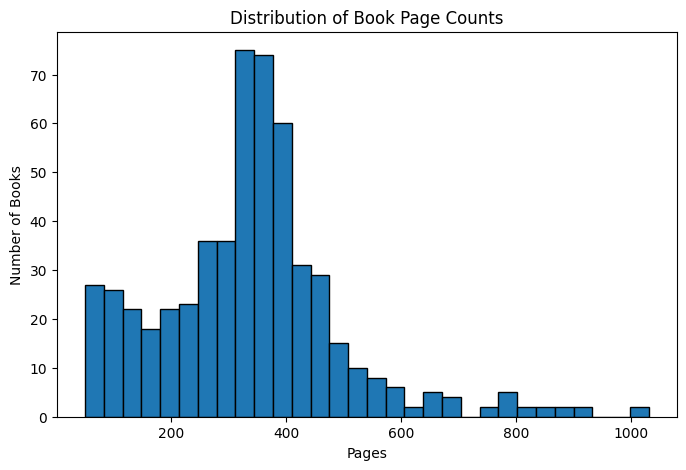

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["pages"], bins=30, edgecolor="black")
plt.title("Distribution of Book Page Counts")
plt.xlabel("Pages")
plt.ylabel("Number of Books")
plt.show()

## Ratings distribution

Average ratings are concentrated in a narrow band, suggesting most books are rated moderately well rather than extremely poorly or exceptionally highly.

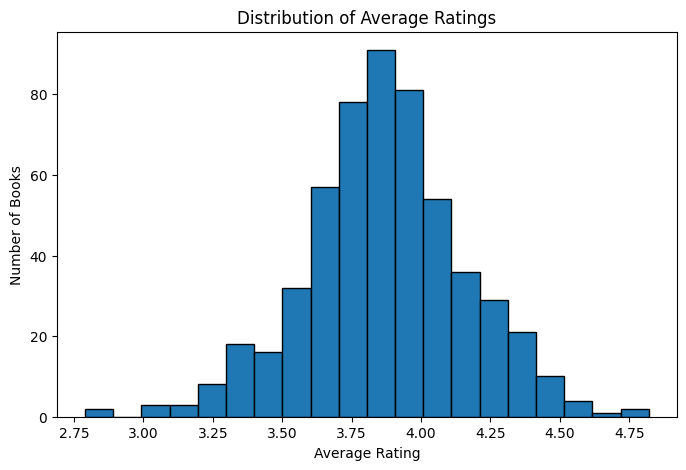

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df["rating"], bins=20, edgecolor="black")
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")
plt.show()

## Scatter plot: pages vs rating

The scatter plot supports the correlation result: there is a slight upward trend, but the relationship is weak and highly variable.

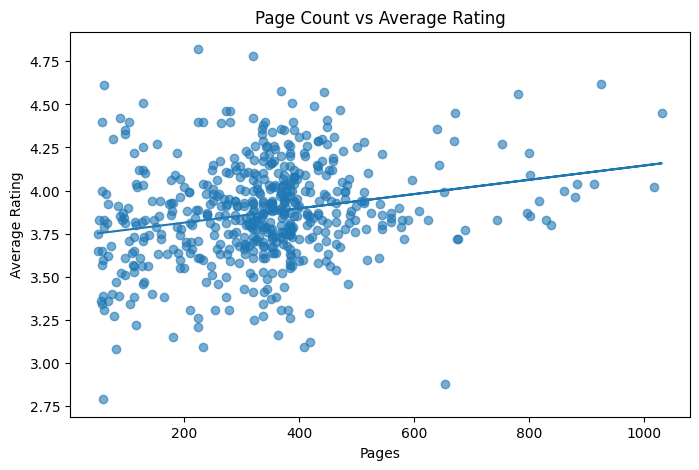

In [22]:
import numpy as np

x = df["pages"]
y = df["rating"]
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.6)
plt.plot(x, m*x + b)
plt.title("Page Count vs Average Rating")
plt.xlabel("Pages")
plt.ylabel("Average Rating")
plt.show()

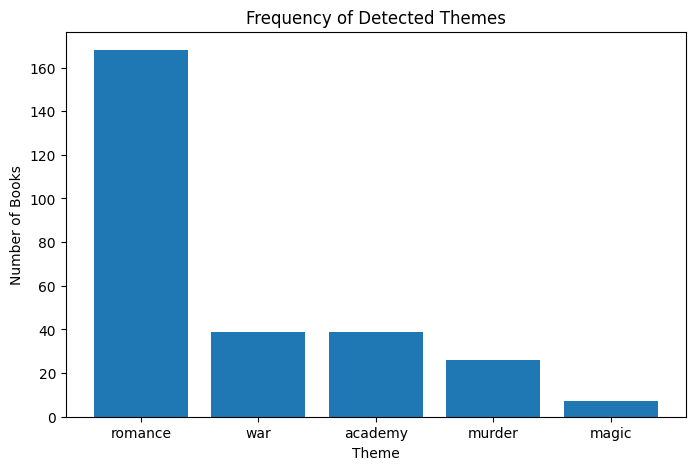

In [23]:
plt.figure(figsize=(8,5))
plt.bar(theme_frequency["theme"], theme_frequency["count"])
plt.title("Frequency of Detected Themes")
plt.xlabel("Theme")
plt.ylabel("Number of Books")
plt.show()

## Conclusion